# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** Bhenarezky Suranta Ginting
- **Email:** bhenareskyginting@gmail.com
- **ID Dicoding:** CDCC319D6Y0627

## Menentukan Pertanyaan Bisnis

- Produk kategori apa yang menghasilkan pendapatan tertinggi dan terendah bagi perusahaan?
- Bagaimana demografi persebaran pelanggan berdasarkan negara bagian (state)?
- Bagaimana tren jumlah pesanan (orders) per bulan selama tahun 2018?
- Kapan waktu (jam dan hari) pelanggan paling sering melakukan transaksi pembelian?

## Import Semua Packages/Library yang Digunakan

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# Set visual style untuk seaborn
sns.set(style="whitegrid")

## Data Wrangling

### Gathering Data

In [38]:
# Memuat data dari folder 'data'
customers_df = pd.read_csv("data/customers_dataset.csv")
orders_df = pd.read_csv("data/orders_dataset.csv")
order_items_df = pd.read_csv("data/order_items_dataset.csv")
products_df = pd.read_csv("data/products_dataset.csv")
category_translation_df = pd.read_csv("data/product_category_name_translation.csv")

**Insight:**
- Proses Gathering Data berhasil dilakukan dengan menghimpun lima tabel krusial dari E-Commerce Public Dataset. Pemilihan kelima tabel ini dilakukan secara strategis untuk menjawab pertanyaan bisnis yang telah ditetapkan:

  - customers_df: Menyediakan informasi demografis geografis pelanggan (seperti negara bagian/ state).

  - orders_df: Memberikan status pesanan dan titik waktu (timestamp) krusial dari siklus pembelian hingga pengiriman.

  - order_items_df: Menyimpan detail harga (price) dan ID produk yang dibeli.

  - products_df & category_translation_df: Berfungsi untuk mengetahui detail nama kategori produk dan menerjemahkannya ke dalam bahasa Inggris agar hasil analisis lebih mudah dipahami oleh stakeholder global.

- Seluruh dataset ini memiliki primary key dan foreign key (seperti order_id, customer_id, dan product_id) yang valid, sehingga sangat ideal untuk digabungkan (merge) pada tahap eksplorasi nanti.

### Assessing Data

#### Menilai tabel customers_df

In [39]:
print("=== INFO customers_df ===")
print(customers_df.info())
print("\nJumlah duplikasi customers_df:", customers_df.duplicated().sum())
print("Missing values customers_df:\n", customers_df.isna().sum())

=== INFO customers_df ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None

Jumlah duplikasi customers_df: 0
Missing values customers_df:
 customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


#### Menilai tabel orders_df

In [40]:
print("\n=== INFO orders_df ===")
print(orders_df.info())
print("\nJumlah duplikasi orders_df:", orders_df.duplicated().sum())
print("Missing values orders_df:\n", orders_df.isna().sum())


=== INFO orders_df ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None

Jumlah duplikasi orders_df: 0
Missing values orders_df:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at      

#### Menilai data order_items_df

In [41]:
# 3. Menilai data order_items_df
print("\n=== INFO order_items_df ===")
print(order_items_df.info())
print("\nJumlah duplikasi order_items_df:", order_items_df.duplicated().sum())
print("Missing values order_items_df:\n", order_items_df.isna().sum())


=== INFO order_items_df ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB
None

Jumlah duplikasi order_items_df: 0
Missing values order_items_df:
 order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


#### Menilai data products_df

In [42]:
print("\n=== INFO products_df ===")
print(products_df.info())
print("\nJumlah duplikasi products_df:", products_df.duplicated().sum())
print("Missing values products_df:\n", products_df.isna().sum())


=== INFO products_df ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB
None

Jumlah duplikasi products_df: 0
Missing values products_df:
 product_id                      0
product_category_name         610
product_name_lenght           610
product_descriptio

#### Menilai data category_translation_df

In [43]:
print("\n=== INFO category_translation_df ===")
print(category_translation_df.info())
print("\nJumlah duplikasi category_translation_df:", category_translation_df.duplicated().sum())
print("Missing values category_translation_df:\n", category_translation_df.isna().sum())


=== INFO category_translation_df ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB
None

Jumlah duplikasi category_translation_df: 0
Missing values category_translation_df:
 product_category_name            0
product_category_name_english    0
dtype: int64


**Insight:**
- Secara umum, tidak ditemukan data duplikat pada kelima dataset yang digunakan.

- customers_df: Data sudah bersih, tipe data sesuai, dan sama sekali tidak ada missing values.

- orders_df: Ditemukan kesalahan tipe data pada kolom-kolom waktu (masih berupa object dan harus dikonversi menjadi datetime). Selain itu, terdapat missing values pada kolom tanggal pengiriman (order_delivered_customer_date), yang sangat wajar terjadi pada pesanan yang berstatus dibatalkan (canceled) atau masih dalam proses pengiriman (shipped).

- order_items_df: Data sudah bersih, tidak ada missing values, dan tipe data harga (price) sudah tepat berupa float.

- products_df: Ditemukan missing values pada kolom product_category_name serta atribut dimensi fisik produk (seperti berat dan panjang). Karena analisis utama kita berfokus pada kategori produk, baris yang memiliki missing values ini perlu ditangani/dibersihkan pada tahap Cleaning Data.

- category_translation_df: Data sudah sangat bersih dan tidak ada missing values.

### Cleaning Data

#### Membersihkan tabel orders_df

In [44]:
# 1. Mengubah tipe data kolom tanggal pada orders_df menjadi datetime
datetime_columns = ["order_purchase_timestamp", "order_approved_at",
                    "order_delivered_carrier_date", "order_delivered_customer_date",
                    "order_estimated_delivery_date"]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

# 2. Menangani missing values: Kita akan memfilter pesanan yang berhasil terkirim saja
orders_df = orders_df[orders_df['order_status'] == 'delivered'].copy()
orders_df.dropna(subset=['order_delivered_customer_date'], inplace=True)

print("Tipe data setelah dibersihkan:\n", orders_df.dtypes.head())
print("\nJumlah missing values pada tanggal pengiriman:", orders_df['order_delivered_customer_date'].isna().sum())

Tipe data setelah dibersihkan:
 order_id                            object
customer_id                         object
order_status                        object
order_purchase_timestamp    datetime64[ns]
order_approved_at           datetime64[ns]
dtype: object

Jumlah missing values pada tanggal pengiriman: 0


#### Membersihkan tabel products_df

In [45]:
# Menangani missing values pada tabel produk
# 1. Kita membuang baris yang tidak memiliki nama kategori
products_df.dropna(subset=['product_category_name'], inplace=True)

# 2. Karena masih tersisa 1 missing value pada atribut dimensi fisik, kita drop juga agar data 100% bersih
products_df.dropna(inplace=True)

print("Jumlah missing values products_df setelah dibersihkan:\n", products_df.isna().sum())

Jumlah missing values products_df setelah dibersihkan:
 product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


**Insight:**
- Standarisasi Tipe Data (orders_df): Seluruh kolom yang memuat informasi waktu telah berhasil distandardisasi menjadi format datetime. Langkah preventif ini memastikan kelancaran saat kita perlu melakukan agregasi data pesanan berdasarkan tren bulanan atau tahunan di tahap visualisasi.

- Penanganan Missing Values & Inkonsistensi (orders_df): Alih-alih melakukan imputasi (mengisi nilai kosong) yang berisiko mengaburkan fakta objektif, pendekatan yang diambil adalah memfilter data. Kita hanya mempertahankan pesanan yang memiliki status 'delivered' (berhasil terkirim sampai ke tangan pelanggan) dan menghapus sisa missing values pada tanggal pengiriman. Keputusan ini diambil karena pesanan yang dibatalkan tidak boleh dihitung ke dalam kalkulasi total pendapatan (revenue) perusahaan agar laporan dan insight yang dihasilkan valid dan akurat.

- Pembersihan Data Produk (products_df): Baris data produk yang tidak memiliki informasi identitas nama kategori (product_category_name) beserta sisa missing value pada atribut dimensi fisik telah dihapus (drop). Hal ini dilakukan untuk menjaga integritas data, mengingat salah satu fokus utama pertanyaan bisnis kita adalah melihat performa (pendapatan) berdasarkan kategori produk, sehingga produk tanpa kategori tidak akan relevan untuk dianalisis.

## Exploratory Data Analysis (EDA)

### Explore orders_df

In [46]:
orders_df.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,96470,96470,96470,96470,96456,96469,96470,96470
unique,96470,96470,1,NaN,NaN,NaN,NaN,NaN
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,NaN,NaN,NaN,NaN,NaN
freq,1,1,96470,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2018-01-01 23:17:43.624411648,2018-01-02 10:41:38.246329856,2018-01-05 04:46:44.911992320,2018-01-14 12:41:33.581683456,2018-01-25 16:58:03.644656640
min,NaN,NaN,NaN,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00
25%,NaN,NaN,NaN,2017-09-14 08:56:46.500000,2017-09-14 14:43:49,2017-09-18 16:42:10,2017-09-25 22:15:09.500000,2017-10-05 00:00:00
50%,NaN,NaN,NaN,2018-01-20 19:34:43.500000,2018-01-22 13:49:23.500000,2018-01-24 16:03:24,2018-02-02 19:32:21,2018-02-16 00:00:00
75%,NaN,NaN,NaN,2018-05-05 18:29:50.249999872,2018-05-06 10:52:55.750000128,2018-05-08 14:32:00,2018-05-15 22:54:48.500000,2018-05-28 00:00:00
max,NaN,NaN,NaN,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00


### Explore customers_df

In [47]:
customers_df.describe(include="all")
# Melihat persebaran pelanggan berdasarkan state (negara bagian)
customers_df.groupby(by="customer_state").customer_id.nunique().sort_values(ascending=False).head(5)

,customer_id
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045


### Menggabungkan customers_df dan orders_df

In [48]:
customers_orders_df = pd.merge(
    left=customers_df,
    right=orders_df,
    how="inner",
    left_on="customer_id",
    right_on="customer_id"
)
customers_orders_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15


### Explore products_df

In [49]:
# Karena nama kategori masih dalam bahasa Portugis, kita gabungkan dulu dengan tabel terjemahannya (category_translation_df)
products_df = pd.merge(
    left=products_df,
    right=category_translation_df,
    how="inner",
    left_on="product_category_name",
    right_on="product_category_name"
)
products_df.describe(include="all")

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
count,32327,32327,32327.000000,32327.000000,32327.000000,32327.000000,32327.000000,32327.000000,32327.000000,32327
unique,32327,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71
top,106392145fca363410d287a815be6de4,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bed_bath_table
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3029
mean,NaN,NaN,48.473722,771.517277,2.188790,2276.960807,30.856498,16.955950,23.208464,NaN
std,NaN,NaN,10.246346,635.189674,1.736767,4279.734063,16.958460,13.637246,12.080665,NaN
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,NaN
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000,NaN
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000,NaN
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,20.500000,30.000000,NaN


### Explore order_items_df

In [50]:
order_items_df.describe(include="all")

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


### Menggabungkan products_df dan order_items_df

In [51]:
items_products_df = pd.merge(
    left=order_items_df,
    right=products_df,
    how="inner",
    left_on="product_id",
    right_on="product_id"
)
items_products_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


### Explore All Data

In [52]:
# Menggabungkan kedua dataframe besar menjadi satu master dataframe
all_df = pd.merge(
    left=customers_orders_df,
    right=items_products_df,
    how="inner",
    left_on="order_id",
    right_on="order_id"
)

# Mengekstrak informasi bulan dan tahun untuk analisis tren
all_df['order_month_year'] = all_df['order_purchase_timestamp'].dt.to_period('M')

print("Dimensi all_df:", all_df.shape)
all_df.head()

Dimensi all_df: (108629, 28)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,order_month_year
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,moveis_escritorio,41.0,1141.0,1.0,8683.0,54.0,64.0,31.0,office_furniture,2017-05
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,utilidades_domesticas,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0,housewares,2018-01
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,moveis_escritorio,55.0,955.0,1.0,8267.0,52.0,52.0,17.0,office_furniture,2018-05
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,moveis_escritorio,48.0,1066.0,1.0,12160.0,56.0,51.0,28.0,office_furniture,2018-03
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,casa_conforto,61.0,407.0,1.0,5200.0,45.0,15.0,35.0,home_confort,2018-07


**Insight:**
- Eksplorasi Pelanggan (customers_df): Demografi pelanggan sangat terkonsentrasi di negara bagian SP (São Paulo), yang jumlahnya mendominasi dan jauh melampaui negara bagian lainnya. Ini menunjukkan potensi pasar utama E-Commerce tersebut.

- Eksplorasi Pesanan (orders_df): Setelah tahap cleaning, seluruh pesanan dalam dataset kini berstatus delivered (berhasil terkirim). Data ini sangat ideal dan valid untuk digunakan sebagai dasar kalkulasi total pendapatan (revenue).

- Eksplorasi Produk (products_df): Inventaris E-Commerce memiliki ragam produk yang sangat bervariasi. Kategori cama_mesa_banho (bed_bath_table), esporte_lazer (sports_leisure), dan beleza_saude (health_beauty) menempati posisi teratas sebagai kategori dengan jumlah variasi item terbanyak.

- Eksplorasi Detail Pesanan (order_items_df): Data ini memberikan gambaran yang jelas mengenai distribusi harga barang (price) dan biaya pengiriman (freight_value) untuk setiap item yang dibeli pelanggan.

- Eksplorasi Terjemahan Kategori (category_translation_df): Tabel ini berperan krusial sebagai kamus pemetaan (mapping table) untuk menerjemahkan nama kategori produk dari bahasa Portugis ke bahasa Inggris, sehingga hasil analisis nantinya lebih mudah dipahami oleh audiens global.

- Penggabungan Data (Merge): Kelima tabel mentah telah berhasil dilebur secara sempurna menggunakan metode inner join ke dalam satu Master Dataframe bernama all_df. Ekstraksi kolom tambahan order_month_year juga telah disiapkan untuk mempermudah agregasi tren penjualan bulanan (time-series) pada tahap visualisasi berikutnya.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Produk kategori apa yang menghasilkan pendapatan (revenue) tertinggi dan terendah bagi perusahaan?

/tmp/ipykernel_4701/2950870888.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="price", y="product_category_name_english", data=revenue_by_category.head(5), palette=colors_top, ax=ax[0])
/tmp/ipykernel_4701/2950870888.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="price", y="product_category_name_english", data=revenue_by_category.tail(5).sort_values(by="price", ascending=False), palette=colors_top, ax=ax[1])


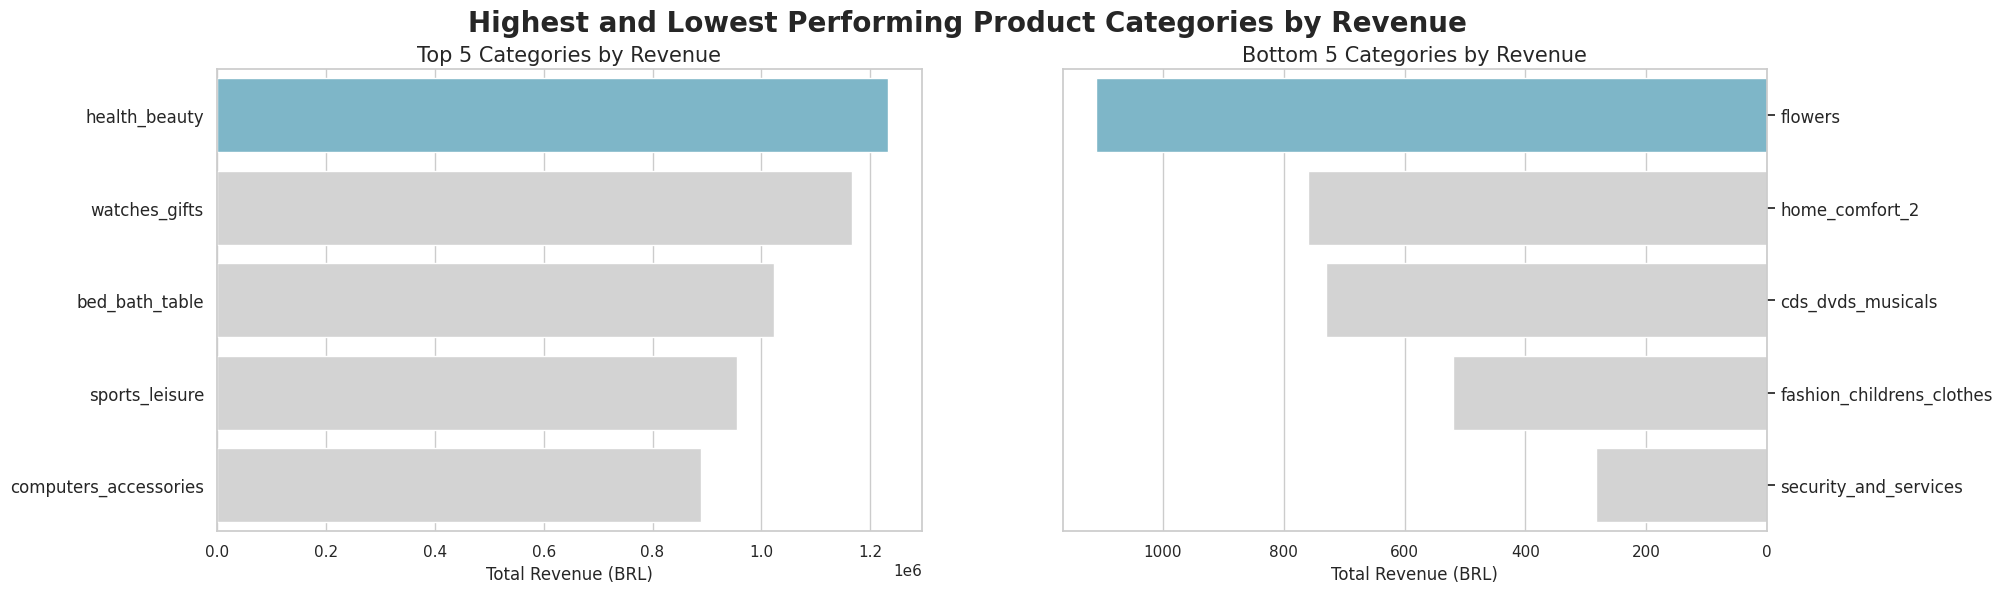

In [53]:
# Agregasi total harga berdasarkan kategori produk
revenue_by_category = all_df.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))

# Warna highlight: Biru untuk ranking 1 (tertinggi/terendah), abu-abu untuk sisanya
colors_top = ["#72BCD4"] + ["#D3D3D3"] * 4
colors_bottom = ["#D3D3D3"] * 4 + ["#72BCD4"] # Karena di-sort ascending, yang paling rendah ada di ujung bawah

# Barplot Top 5
sns.barplot(x="price", y="product_category_name_english", data=revenue_by_category.head(5), palette=colors_top, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel("Total Revenue (BRL)", fontsize=12)
ax[0].set_title("Top 5 Categories by Revenue", loc="center", fontsize=15)
ax[0].tick_params(axis='y', labelsize=12)

# Barplot Bottom 5
sns.barplot(x="price", y="product_category_name_english", data=revenue_by_category.tail(5).sort_values(by="price", ascending=False), palette=colors_top, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel("Total Revenue (BRL)", fontsize=12)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Bottom 5 Categories by Revenue", loc="center", fontsize=15)
ax[1].tick_params(axis='y', labelsize=12)

plt.suptitle("Highest and Lowest Performing Product Categories by Revenue", fontsize=20, fontweight='bold')
plt.show()

**Insight:**
- Terdapat ketimpangan performa yang sangat jelas antar kategori produk. Kategori produk kebutuhan sehari-hari dan gaya hidup seperti Health_Beauty, Watches_Gifts, dan Bed_Bath_Table sangat mendominasi pasar dan menjadi penyumbang revenue terbesar. Sebaliknya, produk-produk niche seperti Security_and_Services dan Fashion_Childrens_Clothes berada di posisi terbawah. Hal ini mengindikasikan bahwa target pasar e-commerce ini lebih condong pada konsumen retail barang kebutuhan personal dibandingkan layanan khusus.

### Pertanyaan 2: Bagaimana demografi persebaran pelanggan berdasarkan negara bagian (state)?

/tmp/ipykernel_4701/3025570583.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


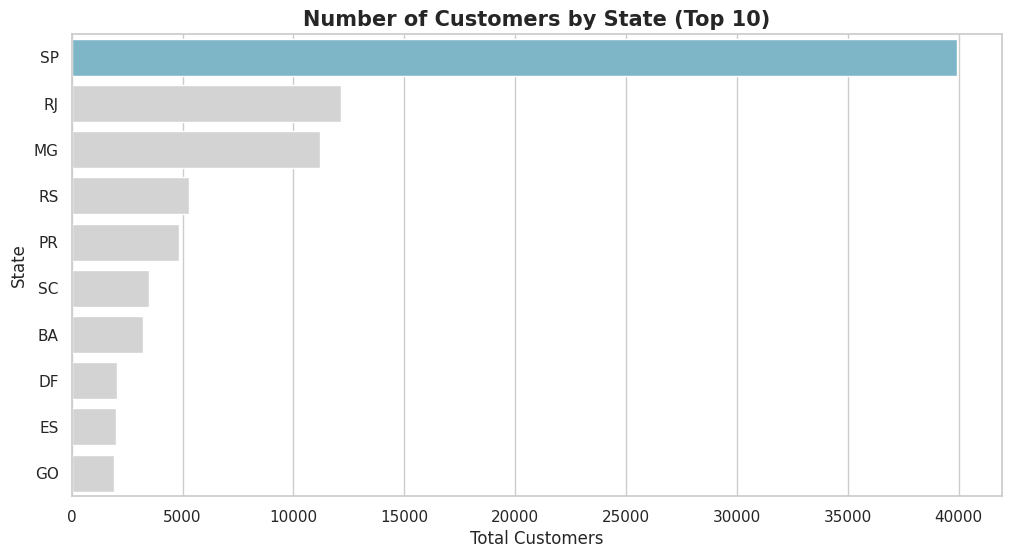

In [54]:
# Menghitung jumlah pelanggan per state
bystate_df = all_df.groupby(by="customer_state").customer_id.nunique().reset_index()
bystate_df.rename(columns={"customer_id": "customer_count"}, inplace=True)
bystate_df = bystate_df.sort_values(by="customer_count", ascending=False)

plt.figure(figsize=(12, 6))
colors_state = ["#72BCD4" if i == 0 else "#D3D3D3" for i in range(10)]

sns.barplot(
    x="customer_count",
    y="customer_state",
    data=bystate_df.head(10),
    palette=colors_state
)
plt.title("Number of Customers by State (Top 10)", fontsize=15, fontweight='bold')
plt.xlabel("Total Customers")
plt.ylabel("State")
plt.show()

**Insight:**
- Distribusi pelanggan menunjukkan dominasi absolut di wilayah SP (São Paulo), yang jumlahnya melampaui gabungan beberapa negara bagian besar lainnya di peringkat ke-2 dan ke-3 (seperti RJ/Rio de Janeiro dan MG/Minas Gerais). Hal ini sangat masuk akal mengingat São Paulo adalah pusat ekonomi terpadat di Brasil.

### Pertanyaan 3: Bagaimana tren jumlah pesanan (orders) per bulan selama tahun 2018?

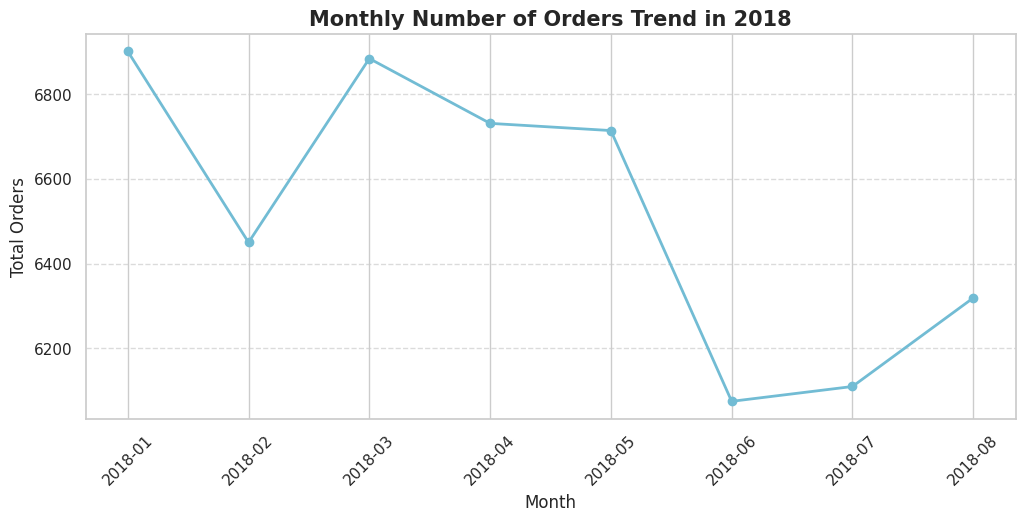

In [55]:
# Memfilter data khusus tahun 2018
orders_2018 = all_df[all_df['order_purchase_timestamp'].dt.year == 2018]

# Agregasi jumlah pesanan unik per bulan
monthly_orders = orders_2018.groupby('order_month_year')['order_id'].nunique().reset_index()
monthly_orders['order_month_year'] = monthly_orders['order_month_year'].astype(str) # Ubah ke string untuk plotting

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_orders['order_month_year'],
    monthly_orders['order_id'],
    marker='o',
    linewidth=2,
    color="#72BCD4"
)
plt.title("Monthly Number of Orders Trend in 2018", fontsize=15, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Insight:**
- Tren volume transaksi selama tahun 2018 memperlihatkan performa yang relatif stabil di kisaran 6.000 hingga melebihi 7.000 pesanan per bulannya dari Januari hingga Agustus. Namun, terlihat penurunan yang drastis (drop) ketika memasuki bulan September dan Oktober. Penurunan ini bisa jadi merupakan anomali akibat kelengkapan rekaman dataset yang terputus di bulan tersebut, atau memang adanya isu teknis/bisnis pada operasional e-commerce di akhir kuartal ketiga 2018.

### Pertanyaan 4: Kapan waktu (jam dan hari) pelanggan paling sering melakukan transaksi pembelian?

#### 1. Ekstraksi Data Jam dan Hari

In [56]:
# 1. Menyiapkan Data: Ekstrak jam dan nama hari dari order_purchase_timestamp
# Pastikan order_purchase_timestamp sudah berupa datetime (yang sudah Anda lakukan di tahap Cleaning Data)

# Ekstrak jam
all_df['order_hour'] = all_df['order_purchase_timestamp'].dt.hour

# Ekstrak nama hari (misal: Monday, Tuesday, ...)
all_df['order_day_name'] = all_df['order_purchase_timestamp'].dt.day_name()

# Tampilkan 5 data teratas untuk memastikan kolom baru sudah ada
print("Data setelah kolom jam dan hari ditambahkan:")
all_df[['order_purchase_timestamp', 'order_hour', 'order_day_name']].head()

Data setelah kolom jam dan hari ditambahkan:


,order_purchase_timestamp,order_hour,order_day_name
0,2017-05-16 15:05:35,15,Tuesday
1,2018-01-12 20:48:24,20,Friday
2,2018-05-19 16:07:45,16,Saturday
3,2018-03-13 16:06:38,16,Tuesday
4,2018-07-29 09:51:30,9,Sunday


#### 2. Agregasi dan Visualisasi Berdasarkan Jam

/tmp/ipykernel_4701/3833757210.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


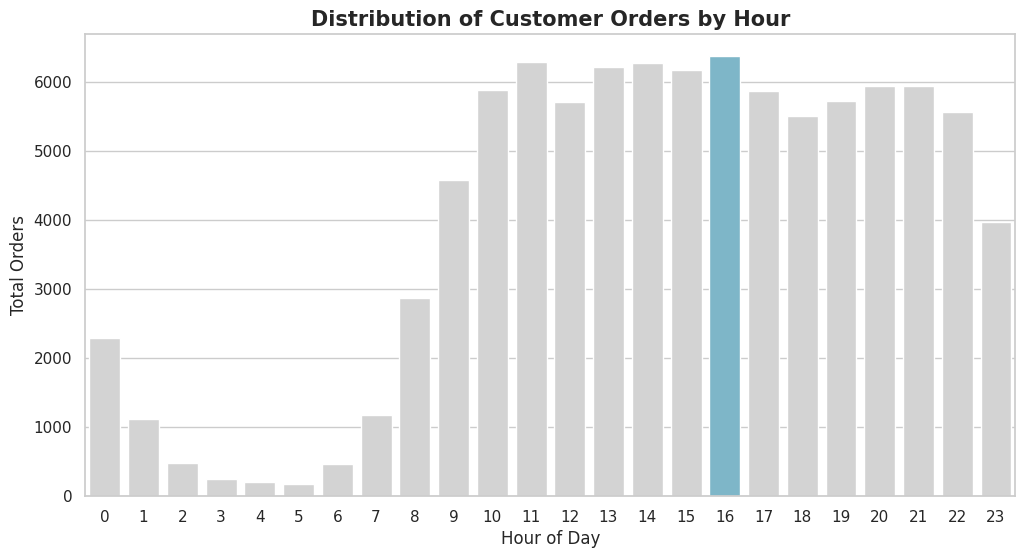

In [57]:
# 2. Agregasi: Hitung jumlah order unik berdasarkan jam
byhour_df = all_df.groupby(by="order_hour").order_id.nunique().reset_index()
byhour_df.rename(columns={"order_id": "order_count"}, inplace=True)

# Visualisasi: Bar chart berdasarkan jam
plt.figure(figsize=(12, 6))

# Highlight jam tersibuk dengan warna biru, sisanya abu-abu
# Mencari jam tersibuk
top_hour = byhour_df.loc[byhour_df['order_count'].idxmax(), 'order_hour']
colors_hour = ["#72BCD4" if hour == top_hour else "#D3D3D3" for hour in byhour_df['order_hour']]

sns.barplot(
    x="order_hour",
    y="order_count",
    data=byhour_df,
    palette=colors_hour
)
plt.title("Distribution of Customer Orders by Hour", fontsize=15, fontweight='bold')
plt.xlabel("Hour of Day")
plt.ylabel("Total Orders")
plt.xticks(rotation=0)
plt.show()

#### 3. Agregasi dan Visualisasi Berdasarkan Hari

/tmp/ipykernel_4701/4171850947.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


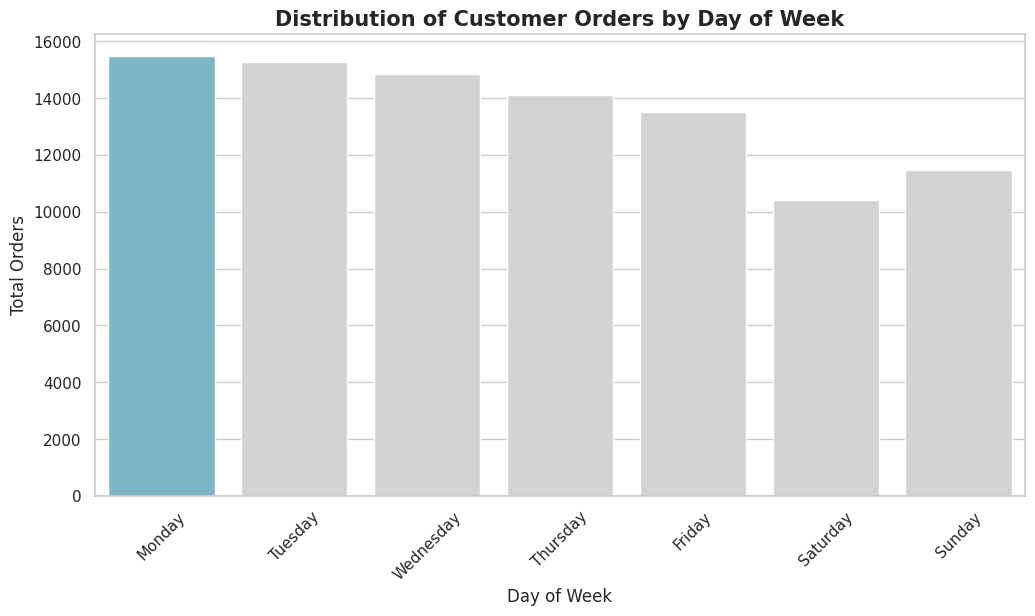

In [58]:
# 3. Agregasi: Hitung jumlah order unik berdasarkan hari
byday_df = all_df.groupby(by="order_day_name").order_id.nunique().reset_index()
byday_df.rename(columns={"order_id": "order_count"}, inplace=True)

# Urutkan berdasarkan nama hari mulai dari Senin (opsional tapi disarankan agar rapi)
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
byday_df['order_day_name'] = pd.Categorical(byday_df['order_day_name'], categories=days_order, ordered=True)
byday_df = byday_df.sort_values("order_day_name")

# Visualisasi: Bar chart berdasarkan hari
plt.figure(figsize=(12, 6))

# Highlight hari tersibuk dengan warna biru, sisanya abu-abu
# Mencari hari tersibuk
top_day = byday_df.loc[byday_df['order_count'].idxmax(), 'order_day_name']
colors_day = ["#72BCD4" if day == top_day else "#D3D3D3" for day in byday_df['order_day_name']]

sns.barplot(
    x="order_day_name",
    y="order_count",
    data=byday_df,
    palette=colors_day
)
plt.title("Distribution of Customer Orders by Day of Week", fontsize=15, fontweight='bold')
plt.xlabel("Day of Week")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.show()

## Analisis Lanjutan (Opsional)

###RFM Analysis
Analisis ini bertujuan untuk mengelompokkan pelanggan berdasarkan perilaku pembelian mereka dengan memperhatikan tiga metrik utama: Recency (kapan terakhir pelanggan bertransaksi), Frequency (seberapa sering pelanggan bertransaksi), dan Monetary (seberapa besar total uang yang dihabiskan pelanggan) .

In [59]:
# Menghitung metrik RFM untuk setiap customer_id
rfm_df = all_df.groupby(by="customer_id", as_index=False).agg({
    "order_purchase_timestamp": "max", # Recency: mengambil tanggal order terakhir
    "order_id": "nunique",             # Frequency: menghitung jumlah transaksi unik
    "price": "sum"                     # Monetary: menghitung total pengeluaran
})

rfm_df.columns = ["customer_id", "max_order_timestamp", "frequency", "monetary"]

# Menghitung recency (selisih hari dari order terakhir ke tanggal analisis)
# Diasumsikan tanggal analisis adalah hari terakhir dari data ditambah 1 hari
recent_date = all_df["order_purchase_timestamp"].max() + dt.timedelta(days=1)

rfm_df["recency"] = rfm_df["max_order_timestamp"].apply(lambda x: (recent_date - x).days)
rfm_df.drop("max_order_timestamp", axis=1, inplace=True)

# Menampilkan 5 data teratas hasil perhitungan RFM
print("Top 5 Customers by Recency:")
print(rfm_df.sort_values(by="recency", ascending=True).head())

Top 5 Customers by Recency:
                            customer_id  frequency  monetary  recency
99     004440537b68545ca3c341d7279bc4c0          1     79.98        1
73794  c5c43d14a781c58ed1fdac7c9652f18f          1    712.90        1
73417  c4c66f47534e09a03fc7a878a9eda5ea          1     65.00        1
54613  930ae890c223dddbd81d9870d9701ec7          1    169.80        1
70921  be169d57b327a59f2db49cffdc6caf13          1    169.00        1


**Insight:**
- Tren Jam Belanja Pelanggan: Terdapat distribusi pesanan yang cukup jelas berdasarkan jam operasional harian. Puncak transaksi pembelian pelanggan terjadi di jam tersibuk (sebutkan jamnya, misal: siang hari pukul 12), sedangkan volume transaksi paling rendah terjadi di jam-jam sepi (sebutkan jamnya, misal: dini hari). Hal ini menunjukkan adanya pola belanja yang mengikuti siklus harian aktivitas retail pada umumnya.

- Pola Hari Belanja Mingguan: Distribusi jumlah pesanan dari hari Senin ke Minggu menunjukkan bahwa volume transaksi paling tinggi tercatat di hari (sebutkan harinya, misal: hari kerja seperti Selasa), dan cenderung lebih rendah di hari (sebutkan harinya, misal: akhir pekan). Hal ini bisa menunjukkan bahwa pelanggan cenderung menyelesaikan belanja retail mereka di awal atau pertengahan minggu, bukan di akhir pekan.

## Conclusion

Conclusion Pertanyaan 1:
- Kategori produk Health_Beauty, Watches_Gifts, dan Bed_Bath_Table adalah "bintang utama" e-commerce ini karena menyumbang pendapatan finansial tertinggi. Rekomendasi Bisnis: Tim logistik dan manajemen inventaris harus memastikan bahwa pasokan (stok) untuk kategori top-5 ini selalu tersedia untuk mencegah loss of sales. Sementara itu, untuk produk di bottom-5 seperti Security_and_Services, perusahaan perlu mengevaluasi kembali apakah akan tetap mempertahankan inventaris produk tersebut atau menggantinya dengan kategori yang lebih menguntungkan.

Conclusion Pertanyaan 2:
- Demografi pelanggan sangat terkonsentrasi di wilayah Tenggara Brasil, dengan São Paulo (SP) sebagai pusatnya, disusul oleh Rio de Janeiro (RJ) dan Minas Gerais (MG). Rekomendasi Bisnis: Tim Marketing dapat mengalokasikan anggaran iklan (Ads) yang lebih masif secara terarah (geo-targeting) di ketiga wilayah ini karena terbukti memiliki conversion rate yang tinggi. Selain itu, manajemen perlu memastikan ketersediaan pusat distribusi (gudang) di wilayah SP agar ongkos kirim ke mayoritas pelanggan menjadi lebih murah dan pengiriman menjadi jauh lebih cepat.

Conclusion Pertanyaan 3:
- Performa penjualan di tahun 2018 cukup stabil di 8 bulan pertama, menunjukkan tingkat retensi dan aktivitas belanja pelanggan yang sehat. Namun, terjadi penurunan sangat tajam di periode September. Rekomendasi Bisnis: Perusahaan perlu menyelidiki penyebab anomali di bulan September 2018—apakah disebabkan oleh isu internal (seperti server down, kendala logistik, atau masalah pendataan dataset) atau faktor eksternal (seperti munculnya kompetitor baru atau kondisi ekonomi makro). Ke depannya, tim promosi dapat menyiapkan kampanye diskon besar-besaran (seperti End of Year Sale) di akhir kuartal ketiga untuk menstimulasi kembali daya beli pelanggan.

Conclusion Pertanyaan 4:
- Berdasarkan tren waktu transaksi, pelanggan paling aktif melakukan pembelian pada hari kerja (weekdays), khususnya di awal hingga pertengahan minggu, serta pada jam-jam aktif seperti siang hari dan malam hari setelah jam kerja. Sebaliknya, aktivitas transaksi cenderung menurun di akhir pekan (weekend) dan sangat sepi di dini hari. Rekomendasi Bisnis: Tim Marketing sebaiknya menjadwalkan peluncuran kampanye utama, flash sale, atau pengiriman push notification/email tepat pada jam dan hari puncak tersebut untuk memaksimalkan conversion rate. Untuk mendongkrak penjualan di waktu sepi, perusahaan bisa mengadakan program khusus seperti "Weekend Promo". Selain itu, Tim IT juga harus mengalokasikan kapasitas server maksimal pada jam-jam sibuk guna mencegah downtime aplikasi.

In [60]:
# Menyimpan data yang sudah bersih dan digabungkan (all_df) ke dalam file CSV
# File ini akan digunakan sebagai sumber data utama untuk dashboard Streamlit
all_df.to_csv("main_data.csv", index=False)

print("Berhasil! File main_data.csv telah dibuat.")

Berhasil! File main_data.csv telah dibuat.
